# Benchmark: NeuralMI vs. Classical Estimators

The tutorials in this repository teach you how to use `NeuralMI`. This notebook
answers a different question: **why reach for a neural estimator instead of a
classical one?**

We compare against two families of classical methods on problems chosen to be
hard for them and easy to reason about analytically:

1. **MI estimation in high dimensions** — `NeuralMI` (InfoNCE + `mode='rigorous'`)
   against the KSG estimator (Kraskov, Stögbauer & Grassberger, 2004), a
   k-nearest-neighbour method that is the standard classical choice for
   continuous MI estimation.
2. **Intrinsic dimensionality under observation noise** — `NeuralMI`'s
   paired-view participation-ratio (PR) protocol (`mode='dimensionality'`)
   against two purely geometric intrinsic-dimension (ID) estimators: the
   Levina–Bickel MLE estimator and Two-NN, both via `scikit-dimension`.

**Scope note.** This is a positioning notebook, not a new library feature.
KSG and the ID estimators are the *foil* here, not something `NeuralMI`
wraps or dispatches to — there is no `estimator='ksg'` option, and there
won't be. The two comparison packages are installed in the next cell, only
for this notebook; they are not `NeuralMI` dependencies.

In [1]:
# Only needed for this notebook -- not NeuralMI dependencies.
import sys
!{sys.executable} -m pip install --quiet benchmark-mi scikit-dimension

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bmi
import skdim
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(0)

## Part 1 — MI Estimation in High Dimensions: NeuralMI vs. KSG

**Setup.** We use `nmi.generators.generate_nonlinear_from_latent` to build two
observed variables, each 500-dimensional, that share a 10-dimensional latent
with a known ground-truth mutual information of **4.0 bits**. This is exactly
the kind of "many observed channels, few informative latent dimensions"
problem that real neural recordings pose, and it is deliberately hard for a
k-nearest-neighbour method: KSG's neighbour-distance statistics become
uninformative as the ambient dimension grows (the "curse of dimensionality"),
while a trained neural critic only has to find the informative subspace.

We test both an **undersampled** regime (N=500) and a **well-sampled** regime
(N=10,000).

In [3]:
K, D_LATENT, MI_TRUE = 500, 10, 4.0
K_SWEEP = [3, 5, 10, 20, 40]  # KSG neighbour counts
N_VALUES = (500, 10000)  # undersampled, well-sampled

exp1_data = {}
for N in N_VALUES:
    x, y = nmi.generators.generate_nonlinear_from_latent(
        n_samples=N, latent_dim=D_LATENT, observed_dim=K, mi=MI_TRUE, use_torch=False,
    )
    exp1_data[N] = (x.astype('float32'), y.astype('float32'))
    print(f"N={N:6d}  x.shape={exp1_data[N][0].shape}  y.shape={exp1_data[N][1].shape}")

N=   500  x.shape=(500, 500)  y.shape=(500, 500)
N= 10000  x.shape=(10000, 500)  y.shape=(10000, 500)


### KSG across a range of neighbour counts `k`

KSG has no free lunch for choosing `k`: too small and the estimate is noisy;
too large and the local-density assumption breaks down. In low dimensions,
averaging or extrapolating across `k` usually stabilises the estimate. We
sweep `k` here to show that in *this* high-dimensional regime, there is no
such stable extrapolation target — the estimate keeps drifting as `k` changes,
and it never approaches the 4.0-bit truth at either sample size.

`bmi`'s KSG estimator reports mutual information in **nats**; we convert to
bits for a direct comparison with `NeuralMI`'s reported units.

In [4]:
ksg_results = {}
for N, (x, y) in exp1_data.items():
    ksg_results[N] = {}
    for k in K_SWEEP:
        t0 = time.time()
        ksg = bmi.estimators.KSGEnsembleFirstEstimator(neighborhoods=(k,))
        est_nats = ksg.estimate(x.astype('float64'), y.astype('float64'))
        est_bits = est_nats / np.log(2)
        ksg_results[N][k] = est_bits
        print(f"N={N:6d}  KSG k={k:3d}  MI={est_bits:.3f} bits  ({time.time()-t0:.1f}s)")

N=   500  KSG k=  3  MI=1.563 bits  (0.3s)


N=   500  KSG k=  5  MI=1.341 bits  (0.7s)


N=   500  KSG k= 10  MI=1.143 bits  (0.6s)


N=   500  KSG k= 20  MI=0.950 bits  (0.6s)
N=   500  KSG k= 40  MI=0.725 bits  (0.2s)


N= 10000  KSG k=  3  MI=2.284 bits  (24.9s)


N= 10000  KSG k=  5  MI=2.171 bits  (28.1s)


N= 10000  KSG k= 10  MI=1.999 bits  (34.5s)


N= 10000  KSG k= 20  MI=1.819 bits  (29.8s)


N= 10000  KSG k= 40  MI=1.627 bits  (28.7s)


### NeuralMI, `mode='rigorous'`

For a fair comparison we use the same recommended workflow as the rest of
this library: `mode='rigorous'` trains on progressively smaller subsets and
extrapolates to the infinite-data limit, giving a bias-corrected estimate
with a confidence interval (Tutorial 5).

In [5]:
model = nmi.Model(hidden_dim=128, embedding_dim=64)
training = nmi.Training(n_epochs=80, patience=30, learning_rate=5e-4)

nmi_results = {}
for N, (x, y) in exp1_data.items():
    t0 = time.time()
    r = nmi.run(
        x, y, mode='rigorous',
        split=nmi.Split(mode='random'),
        model=model, training=training,
        n_workers=4, seed=0, show_progress=False,
    )
    nmi_results[N] = (r.mi_estimate, r.details.get('mi_error'), r.details.get('is_reliable'))
    print(f"N={N:6d}  NeuralMI rigorous MI = {r.mi_estimate:.3f} +/- {r.details.get('mi_error'):.3f} bits  "
          f"(is_reliable={r.details.get('is_reliable')})  ({time.time()-t0:.1f}s)")

2026-07-14 04:39:17 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-07-14 04:39:17 - neural_mi - WARNING - gamma=1: smallest data subset has 500 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-14 04:39:17 - neural_mi - WARNING - gamma=2: smallest data subset has 250 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-14 04:39:17 - neural_mi - WARNING - gamma=3: smallest data subset has 166 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-14 04:39:17 - neural_mi - WARNING - gamma=4: smallest data subset has 125 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


...

2026-07-14 04:41:08 - neural_mi - INFO - Created PairedDataset


2026-07-14 04:41:11 - neural_mi - INFO - Created PairedDataset


2026-07-14 04:41:12 - neural_mi - INFO - Created PairedDataset


2026-07-14 04:41:12 - neural_mi - INFO - Created PairedDataset
2026-07-14 04:41:12 - neural_mi - INFO - Created PairedDataset


N= 10000  NeuralMI rigorous MI = 3.845 +/- 0.050 bits  (is_reliable=True)  (92.6s)


### Comparison

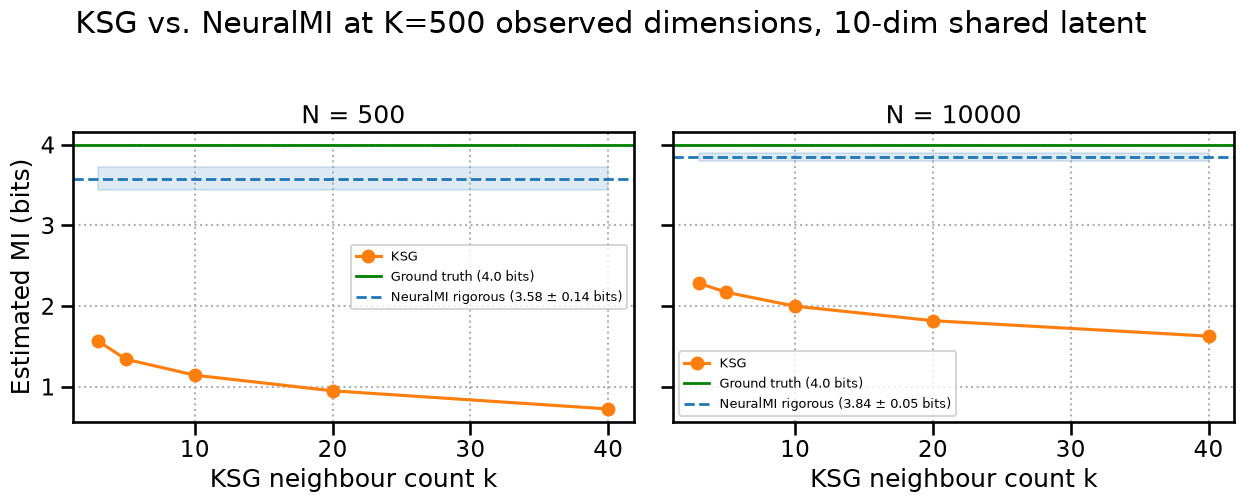

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, N in zip(axes, N_VALUES):
    ks = list(ksg_results[N].keys())
    vals = list(ksg_results[N].values())
    ax.plot(ks, vals, 'o-', color='tab:orange', label='KSG')
    ax.axhline(MI_TRUE, color='green', linestyle='-', linewidth=2, label='Ground truth (4.0 bits)')
    mi_est, mi_err, _ = nmi_results[N]
    ax.axhline(mi_est, color='tab:blue', linestyle='--', linewidth=2,
               label=f'NeuralMI rigorous ({mi_est:.2f} ± {mi_err:.2f} bits)')
    ax.fill_between(ks, mi_est - mi_err, mi_est + mi_err, color='tab:blue', alpha=0.15)
    ax.set_xlabel('KSG neighbour count k')
    ax.set_title(f'N = {N}')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':')
axes[0].set_ylabel('Estimated MI (bits)')
fig.suptitle('KSG vs. NeuralMI at K=500 observed dimensions, 10-dim shared latent', y=1.02)
plt.tight_layout()
plt.show()

KSG's estimate depends heavily on `k` and, at both sample sizes, stays well
below the 4.0-bit ground truth no matter which `k` is chosen — there is no
value of `k` a practitioner could pick in advance that would recover the
truth, and there is no stable plateau to extrapolate to. `NeuralMI`'s
rigorous-mode estimate lands close to the ground truth at both sample sizes,
with a confidence interval that tightens as N grows from 500 to 10,000.

This is not a criticism of KSG in general — it is a strong, well-established
estimator in low dimensions. The point is narrower: once the *observed*
dimension is large, even when the *informative* (latent) dimension is small,
a neighbour-distance-based estimator loses its footing while a trained
critic, whose job is precisely to find the informative subspace, does not.

## Part 2 — Intrinsic Dimensionality Under Observation Noise

**Setup.** We build two 500-dimensional observed views, `X` and `Y`, each a
frozen random nonlinear projection of an independent draw from a **shared
5-dimensional latent** (`generate_nonlinear_from_latent`, latent MI = 4.0
bits — the same generator and ground-truth MI as Part 1, just read for its
dimensionality rather than its MI). We then add independent observation
noise to each view, controlled by a noise-to-signal ratio &eta;: the noise
standard deviation on each view is &eta; times that view's own clean-signal
standard deviation, so &eta;=0 is the clean case and &eta;=1 means the added
noise has the same power as the signal.

We compare three ways of reading off the intrinsic dimensionality of this
noisy K=500-dimensional data:

- **MLE** (Levina–Bickel) and **Two-NN** — purely geometric, single-view
  estimators. They see only the local density of points in one 500-dim cloud
  and have no notion of "signal" vs. "noise": all 500 coordinates look the
  same to them. We run each on `X` and on `Y` separately and average the two.
- **Paired-view PR** — `NeuralMI`'s `mode='dimensionality'`, trained
  end-to-end on the pair `(X, Y)`. Because it is explicitly told which two
  views are supposed to share structure, it can in principle ignore
  variance that is private to one view (i.e. independent per-view noise)
  and track only what both views agree on.

In [7]:
N, K, K_Z = 5000, 500, 5
MI_TRUE_DIM = 4.0
ETA_SWEEP = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]

rng = np.random.default_rng(0)

x_clean, y_clean = nmi.generators.generate_nonlinear_from_latent(
    n_samples=N, latent_dim=K_Z, observed_dim=K, mi=MI_TRUE_DIM, use_torch=False,
)
x_clean, y_clean = x_clean.astype('float32'), y_clean.astype('float32')
var_x, var_y = float(x_clean.var()), float(y_clean.var())
print(f"clean signal variance: x={var_x:.4f}  y={var_y:.4f}")

clean signal variance: x=0.2312  y=0.2102


**A note on `shared_encoder`.** `mode='dimensionality'` defaults to
`shared_encoder=True`, because it was designed around the common case of
splitting *one* population into two channel-halves of the *same* data
source, where a shared embedding network is the natural (and more
sample-efficient) choice. Here `X` and `Y` come from two independently
initialised teacher networks and have their own statistics, so we
explicitly set `shared_encoder=False` — each view gets its own embedding
network, which is the correct setup for interaction dimensionality between
genuinely different variables.

In [8]:
model_dim = nmi.Model(embedding_dim=64, shared_encoder=False)
training_dim = nmi.Training(n_epochs=250, patience=50, learning_rate=3e-4)

dim_results = []
for eta in ETA_SWEEP:
    sigma_x, sigma_y = eta * np.sqrt(var_x), eta * np.sqrt(var_y)
    X = (x_clean + sigma_x * rng.standard_normal(x_clean.shape)).astype('float32')
    Y = (y_clean + sigma_y * rng.standard_normal(y_clean.shape)).astype('float32')

    mle = (skdim.id.MLE().fit(X).dimension_ + skdim.id.MLE().fit(Y).dimension_) / 2
    twonn = (skdim.id.TwoNN().fit(X).dimension_ + skdim.id.TwoNN().fit(Y).dimension_) / 2

    # One-shot: X and Y are the actual data, not something to average multiple
    # random channel-splits over (that machinery is for the single-array
    # split-half case) -- n_splits=1 is the right choice here.
    r = nmi.run(
        X, Y, mode='dimensionality',
        split=nmi.Split(mode='random'),
        model=model_dim, training=training_dim,
        dimensionality=nmi.Dimensionality(n_splits=1),
        n_workers=1, seed=0, show_progress=False,
    )
    df = r.dataframe
    pr_singular = float(df['pr_singular_mean'].iloc[0])
    row = dict(eta=eta, mle=float(mle), twonn=float(twonn), pr_singular=pr_singular)
    dim_results.append(row)
    print(f"eta={eta:.2f}  MLE={mle:5.2f}  TwoNN={twonn:5.2f}  PR(paired-view)={pr_singular:5.2f}")

eta=0.00  MLE= 5.07  TwoNN= 4.99  PR(paired-view)= 4.76


eta=0.10  MLE=11.91  TwoNN=20.70  PR(paired-view)= 4.79


eta=0.25  MLE=36.49  TwoNN=59.85  PR(paired-view)= 4.84


eta=0.50  MLE=70.36  TwoNN=91.88  PR(paired-view)= 4.83


eta=0.75  MLE=87.37  TwoNN=110.15  PR(paired-view)= 3.82


eta=1.00  MLE=96.77  TwoNN=114.56  PR(paired-view)= 4.64


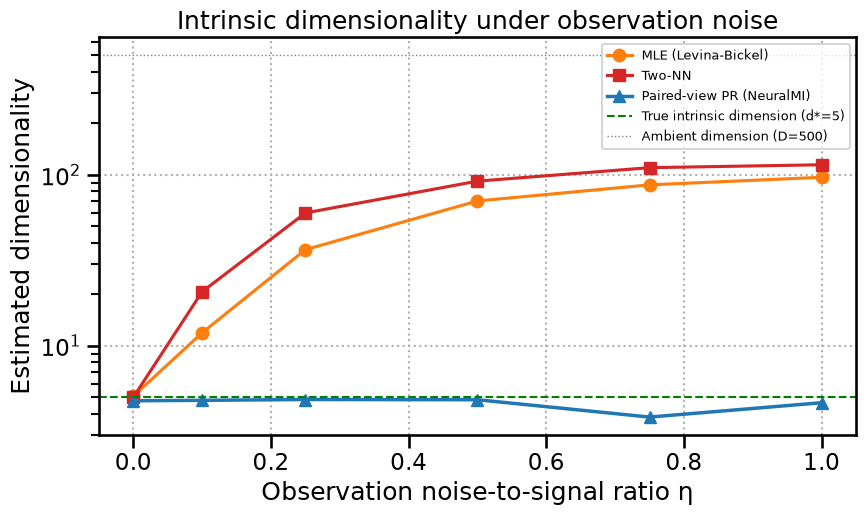

In [9]:
etas = [r['eta'] for r in dim_results]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(etas, [r['mle'] for r in dim_results], 'o-', label='MLE (Levina-Bickel)', color='tab:orange')
ax.plot(etas, [r['twonn'] for r in dim_results], 's-', label='Two-NN', color='tab:red')
ax.plot(etas, [r['pr_singular'] for r in dim_results], '^-', label='Paired-view PR (NeuralMI)', color='tab:blue', linewidth=2.5)
ax.axhline(K_Z, color='green', linestyle='--', linewidth=1.5, label=f'True intrinsic dimension (d*={K_Z})')
ax.axhline(K, color='grey', linestyle=':', linewidth=1, label=f'Ambient dimension (D={K})')
ax.set_xlabel('Observation noise-to-signal ratio η')
ax.set_ylabel('Estimated dimensionality')
ax.set_title('Intrinsic dimensionality under observation noise')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

At `η=0`, all three methods recover something close to the true intrinsic
dimension `d*=5`. As observation noise increases, MLE and Two-NN drift
upward — the added per-view noise inflates the local point-cloud density in
all 500 observed dimensions, and a purely geometric estimator cannot tell
that inflation apart from genuine structure. The paired-view PR estimate
stays much closer to `d*`, because independent noise in `X` cannot help
predict `Y` (and vice versa): a critic trained to extract *shared* structure
between the two views has no incentive to represent noise that only one of
them has.

**What this experiment does not show.** This is a single run per noise
level (no repeated trials), and the specific noise levels, teacher network,
and MI budget are one choice among many that would tell a similar story. It
demonstrates the mechanism, not a exhaustively-validated claim about every
regime.

## Takeaways

- **KSG (and k-NN methods generally) struggle when the observed dimension is
  large**, even when the *informative* dimension is small — exactly the
  situation in most real neural recordings (many channels, few latent
  drivers). `NeuralMI`'s neural estimators do not have this failure mode,
  because a trained critic only has to represent the informative subspace,
  not the full observed geometry.
- **Purely geometric intrinsic-dimension estimators (MLE, Two-NN) cannot
  distinguish per-view noise from genuine shared structure.** `NeuralMI`'s
  paired-view participation-ratio protocol can, because it is trained to
  find what two views have in common.
- Neither comparison means KSG or MLE/Two-NN are bad tools — they are
  simpler, have fewer assumptions, and are often the right choice in low
  dimensions or when training a neural network isn't practical. The point of
  this notebook is narrower: in the specific regime common to modern neural
  recordings (high channel count, low intrinsic dimensionality), the
  trade-offs favour a neural estimator.